In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries imported successfully!")
# This installs a library to read .arff files
import subprocess
subprocess.run(['pip', 'install', 'scipy'])

print("Done")

libraries imported successfully!
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Done


In [9]:
import pandas as pd

# Read the arff file manually
def load_arff_as_df(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Find where data starts
    data_start = 0
    columns = []
    for i, line in enumerate(lines):
        if line.strip().upper().startswith('@ATTRIBUTE'):
            col_name = line.split()[1]
            columns.append(col_name)
        if line.strip().upper() == '@DATA':
            data_start = i + 1
            break
    
    # Read only data lines
    data_lines = [l.strip() for l in lines[data_start:] 
                  if l.strip() and not l.startswith('%')]
    
    from io import StringIO
    csv_data = '\n'.join(data_lines)
    df = pd.read_csv(StringIO(csv_data), header=None, names=columns)
    return df

df = load_arff_as_df('KDDTrain+.arff')
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (125973, 42)


,'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',...,'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class'
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [10]:
# How many rows and columns?
print("Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Check attack types
print("\nAttack Types:")
print(df.iloc[:, -1].value_counts())

Shape: (125973, 42)

Columns: ["'duration'", "'protocol_type'", "'service'", "'flag'", "'src_bytes'", "'dst_bytes'", "'land'", "'wrong_fragment'", "'urgent'", "'hot'", "'num_failed_logins'", "'logged_in'", "'num_compromised'", "'root_shell'", "'su_attempted'", "'num_root'", "'num_file_creations'", "'num_shells'", "'num_access_files'", "'num_outbound_cmds'", "'is_host_login'", "'is_guest_login'", "'count'", "'srv_count'", "'serror_rate'", "'srv_serror_rate'", "'rerror_rate'", "'srv_rerror_rate'", "'same_srv_rate'", "'diff_srv_rate'", "'srv_diff_host_rate'", "'dst_host_count'", "'dst_host_srv_count'", "'dst_host_same_srv_rate'", "'dst_host_diff_srv_rate'", "'dst_host_same_src_port_rate'", "'dst_host_srv_diff_host_rate'", "'dst_host_serror_rate'", "'dst_host_srv_serror_rate'", "'dst_host_rerror_rate'", "'dst_host_srv_rerror_rate'", "'class'"]

Attack Types:
'class'
normal     67343
anomaly    58630
Name: count, dtype: int64


In [11]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nData types:")
print(df.dtypes.value_counts())

Missing values:
0

Data types:
int64      23
float64    15
object      4
Name: count, dtype: int64


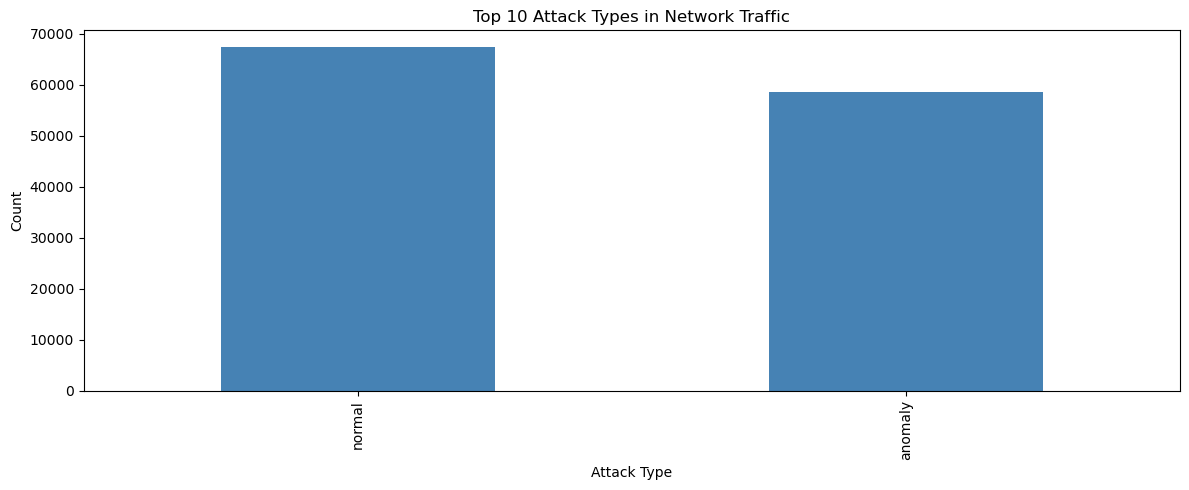

Chart saved!


In [12]:
import matplotlib.pyplot as plt

# Get last column (attack label)
label_col = df.columns[-1]

plt.figure(figsize=(12,5))
df[label_col].value_counts().head(10).plot(
    kind='bar', color='steelblue'
)
plt.title('Top 10 Attack Types in Network Traffic')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('attack_distribution.png')
plt.show()
print("Chart saved!")